# project3 -Fitbit: Calorie Burn Prediction & Workout Pattern Clustering

Step 1: Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully!')

All libraries imported successfully!


Step 2: Data Loading

In [34]:
df = pd.read_csv('Fitbit_dataset.csv')

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Dataset Loaded Successfully!')
print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset Loaded Successfully!
Shape: (14102, 18)
Rows: 14102 | Columns: 18


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [35]:
print('=== Column Names ===')
print(df.columns.tolist())
print('\n=== Data Types ===')
print(df.dtypes)

=== Column Names ===
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)']

=== Data Types ===
Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                          float64
Avg_BPM                          float64
Resting_BPM                      float64
Session_Duration (hours)         float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
Base_MET                         float64
HR_Intensity                     float64
E

Step 3: Basic Data Cleaning

In [36]:
# Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

# Check duplicates
print('\n=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'Duplicates: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')

=== Missing Values ===
No missing values found

=== Duplicate Rows ===
Duplicates: 0


In [37]:
# Drop pre-engineered / data-leaking columns
# Base_MET, HR_Intensity, Effective_MET are mathematically derived from calories
# Keeping them causes data leakage and inflates accuracy to 99%
leaky_cols = ['Base_MET', 'HR_Intensity', 'Effective_MET']
df.drop(columns=leaky_cols, inplace=True)

print(f'Dropped leaky engineered columns: {leaky_cols}')
print(f'Remaining columns ({df.shape[1]}): {df.columns.tolist()}')

Dropped leaky engineered columns: ['Base_MET', 'HR_Intensity', 'Effective_MET']
Remaining columns (15): ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Calories_Burned (kcal)']


In [38]:
# Outlier Capping using IQR method
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((data[col] < lower) | (data[col] > upper)).sum()
    data[col] = data[col].clip(lower, upper)
    return before

numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Outliers capped per column:')
for col in numeric_cols:
    count = cap_outliers(df, col)
    if count > 0:
        print(f'  {col}: {count} outliers capped')
print('Outlier handling complete.')

Outliers capped per column:
  Weight (kg): 93 outliers capped
  Session_Duration (hours): 31 outliers capped
  Fat_Percentage: 10 outliers capped
  Water_Intake (liters): 124 outliers capped
  BMI: 39 outliers capped
  Calories_Burned (kcal): 284 outliers capped
Outlier handling complete.


In [39]:
# One-Hot Encoding for categorical columns
categorical_cols = ['Gender', 'Workout_Type']
print('Before encoding shape:', df.shape)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print('After One-Hot Encoding shape:', df_encoded.shape)
new_cols = [c for c in df_encoded.columns if any(cat in c for cat in categorical_cols)]
print('New OHE columns:', new_cols)
df_encoded.head()

Before encoding shape: (14102, 15)
After One-Hot Encoding shape: (14102, 20)
New OHE columns: ['Gender_Female', 'Gender_Male', 'Workout_Type_Cardio', 'Workout_Type_HIIT', 'Workout_Type_Mixed', 'Workout_Type_Strength', 'Workout_Type_Yoga']


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Calories_Burned (kcal),Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Mixed,Workout_Type_Strength,Workout_Type_Yoga
0,56,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,3,1,20.4,437.7,True,False,False,True,False,False,False
1,46,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,3,0,18.0,22.5,False,True,False,False,False,False,True
2,32,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,3,1,26.5,183.4,True,False,False,True,False,False,False
3,25,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,3,0,28.5,127.2,False,True,False,False,False,False,True
4,38,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,2,0,32.5,240.7,False,True,True,False,False,False,False


Step 4: Exploratory Data Analysis (EDA)

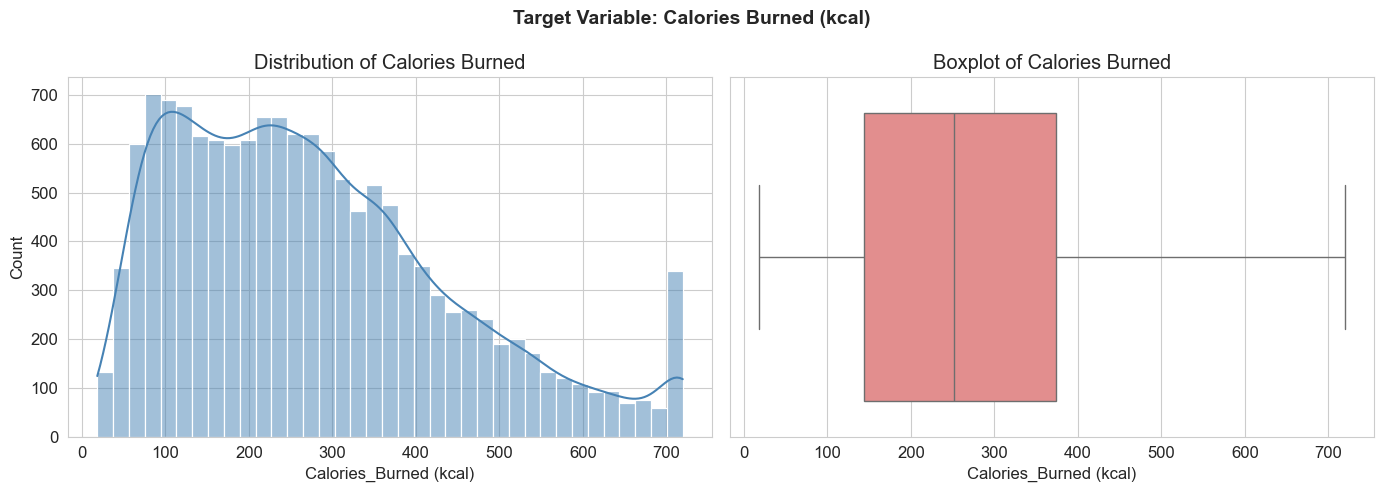

In [40]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Calories_Burned (kcal)'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Calories Burned')
sns.boxplot(x=df['Calories_Burned (kcal)'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Calories Burned')
plt.suptitle('Target Variable: Calories Burned (kcal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

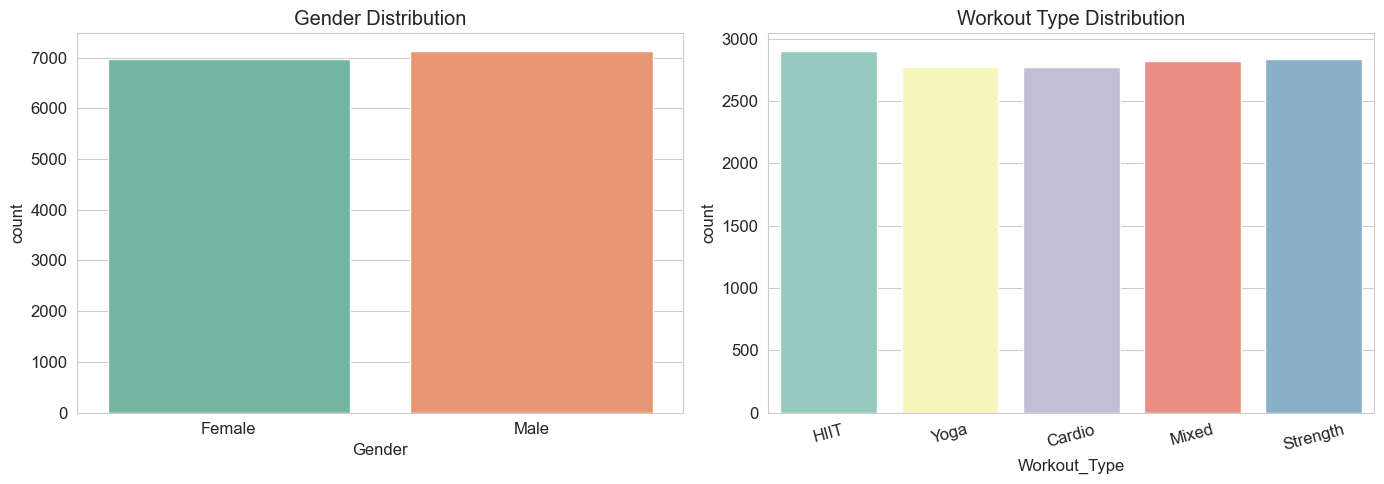

In [41]:
# Categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Gender', ax=axes[0], palette='Set2')
axes[0].set_title('Gender Distribution')
sns.countplot(data=df, x='Workout_Type', ax=axes[1], palette='Set3')
axes[1].set_title('Workout Type Distribution')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

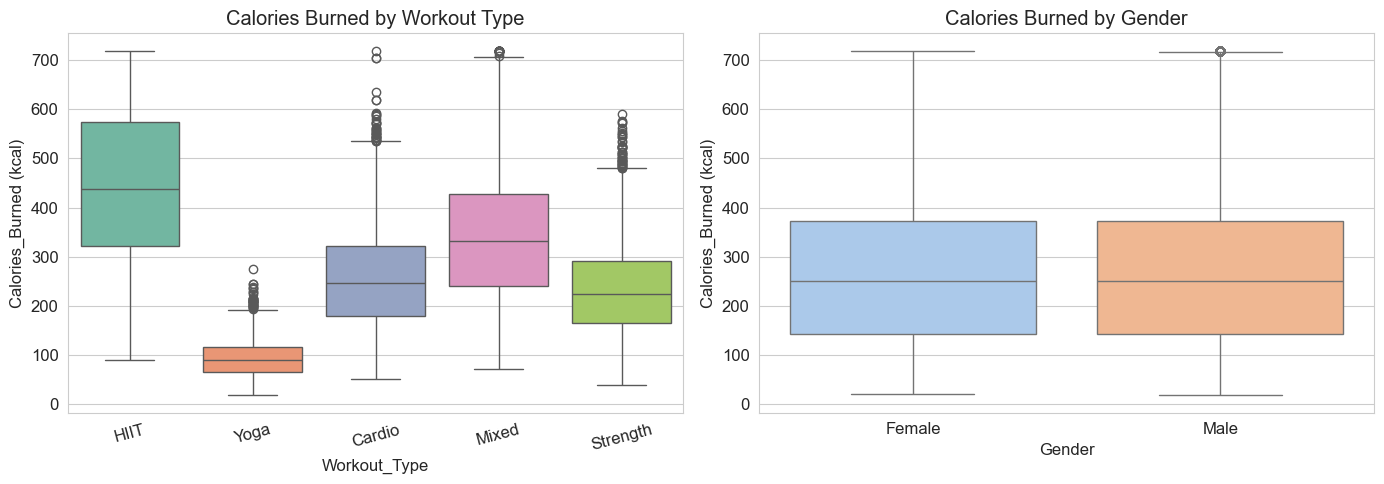

In [42]:
# Calories by Workout Type and Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Workout_Type', y='Calories_Burned (kcal)', ax=axes[0], palette='Set2')
axes[0].set_title('Calories Burned by Workout Type')
axes[0].tick_params(axis='x', rotation=15)
sns.boxplot(data=df, x='Gender', y='Calories_Burned (kcal)', ax=axes[1], palette='pastel')
axes[1].set_title('Calories Burned by Gender')
plt.tight_layout()
plt.savefig('calories_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

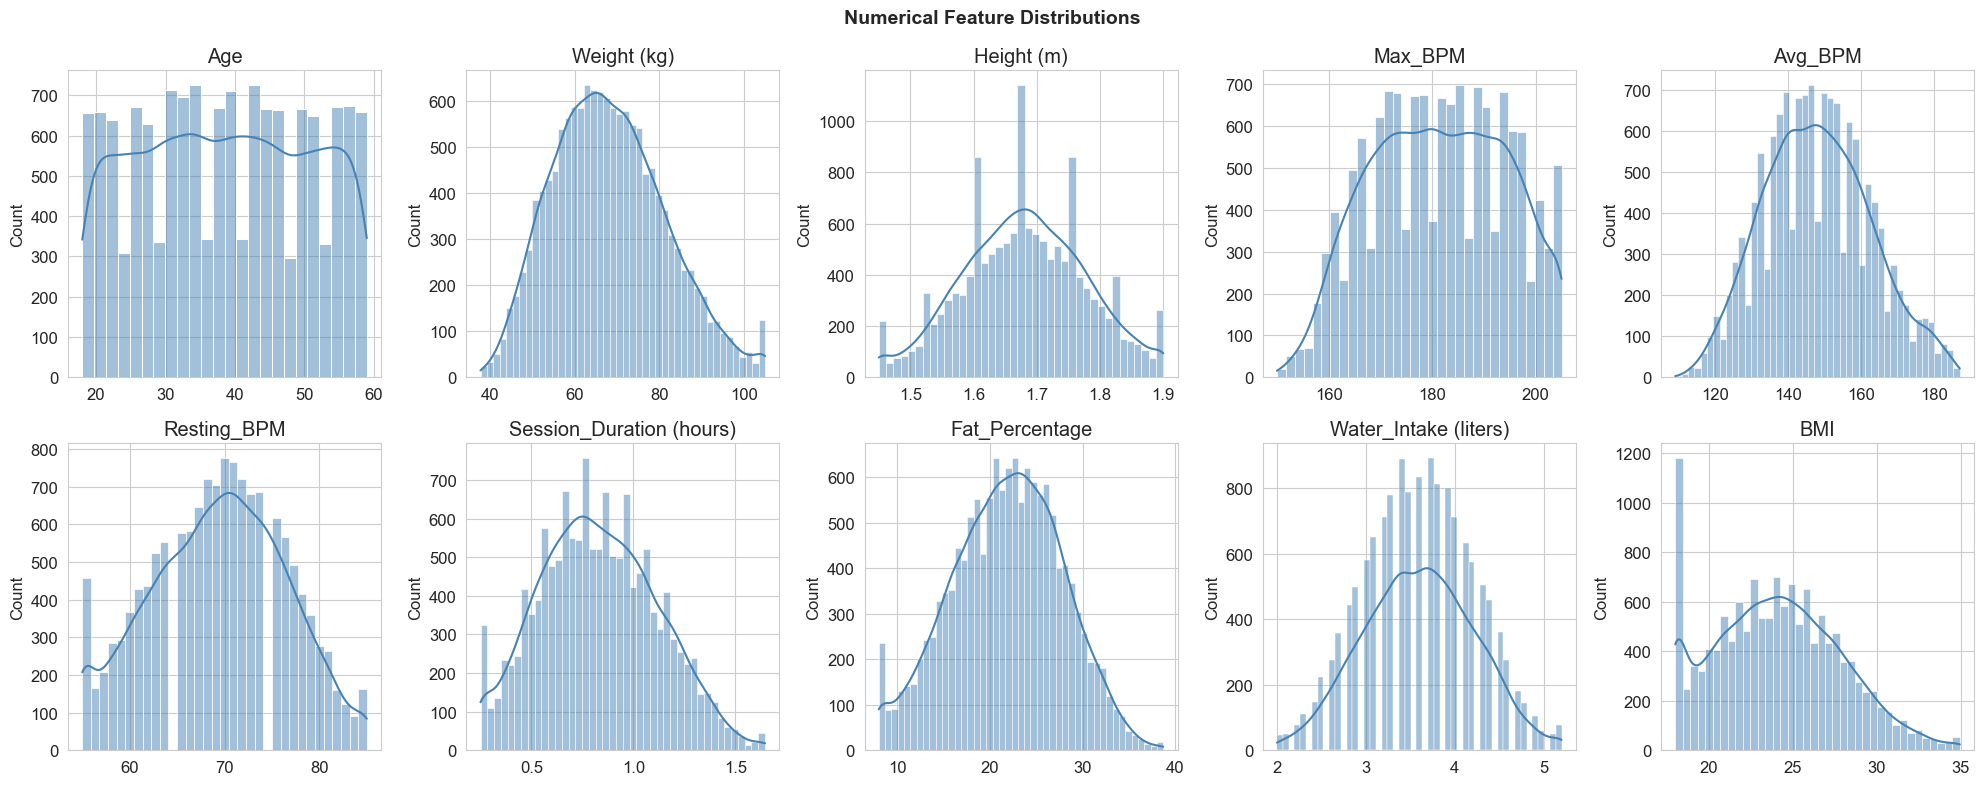

In [67]:
# Numerical feature distributions
num_cols = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
            'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage',
            'Water_Intake (liters)', 'BMI']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Step 5: Correlation Analysis & Feature Selection

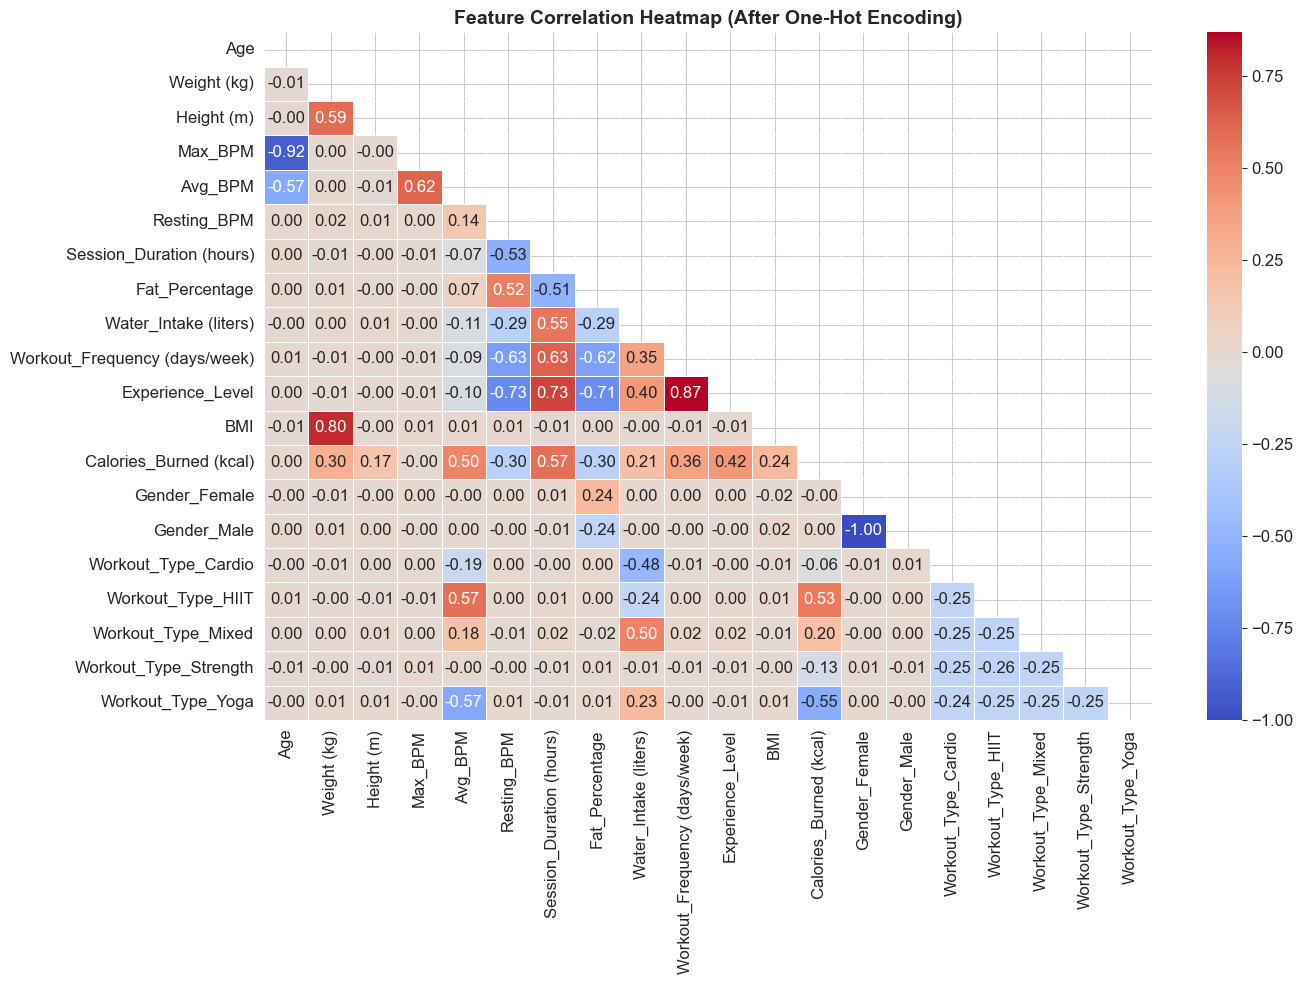

In [44]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5)
plt.title('Feature Correlation Heatmap (After One-Hot Encoding)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Correlation with target — filter features with |corr| > 0.05
corr_with_target = df_encoded.corr()['Calories_Burned (kcal)'].abs().sort_values(ascending=False)
print('=== Correlation with Target ===')
print(corr_with_target)

selected_features = corr_with_target[corr_with_target > 0.05].index.tolist()
selected_features.remove('Calories_Burned (kcal)')

print(f'\nSelected {len(selected_features)} features (|corr| > 0.05):')
print(selected_features)

=== Correlation with Target ===
Calories_Burned (kcal)           1.000000
Session_Duration (hours)         0.573832
Workout_Type_Yoga                0.550938
Workout_Type_HIIT                0.528079
Avg_BPM                          0.495818
Experience_Level                 0.416041
Workout_Frequency (days/week)    0.361553
Weight (kg)                      0.299501
Fat_Percentage                   0.295210
Resting_BPM                      0.295051
BMI                              0.243295
Water_Intake (liters)            0.211757
Workout_Type_Mixed               0.200914
Height (m)                       0.174922
Workout_Type_Strength            0.127651
Workout_Type_Cardio              0.059619
Max_BPM                          0.004597
Gender_Male                      0.004098
Gender_Female                    0.004098
Age                              0.003563
Name: Calories_Burned (kcal), dtype: float64

Selected 15 features (|corr| > 0.05):
['Session_Duration (hours)', 'Workout_Type_Y

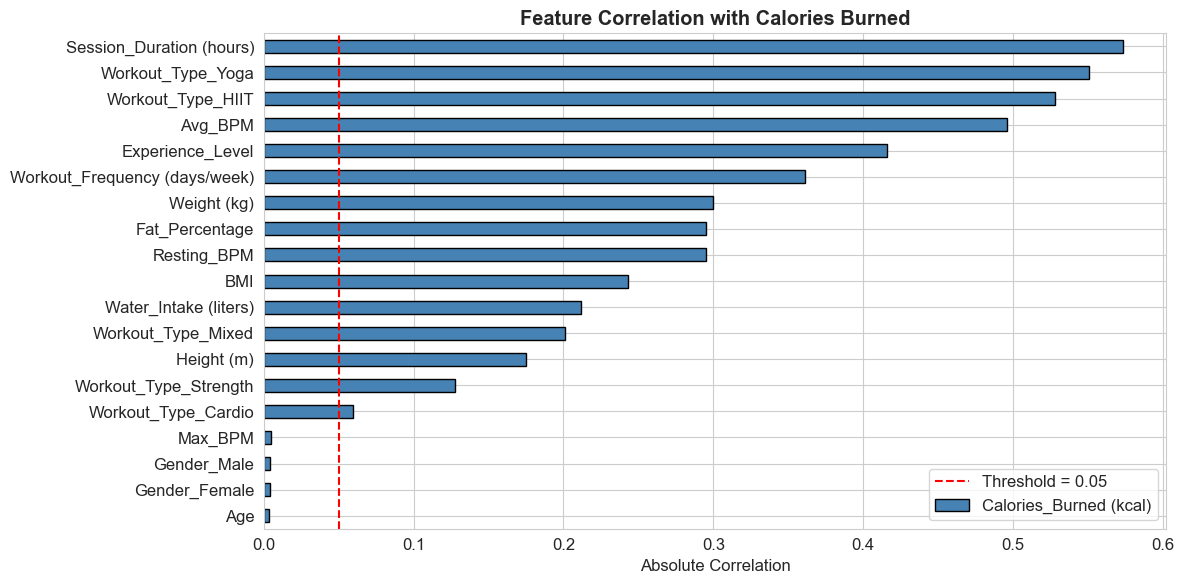

In [46]:
# Feature correlation bar chart
plt.figure(figsize=(12, 6))
corr_with_target.drop('Calories_Burned (kcal)').sort_values().plot(
    kind='barh', color='steelblue', edgecolor='black')
plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold = 0.05')
plt.title('Feature Correlation with Calories Burned', fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

 Step 6: Standard Scaling

In [47]:
X = df_encoded[selected_features]
y = df_encoded['Calories_Burned (kcal)']

print(f'Feature Matrix Shape : {X.shape}')
print(f'Target Shape         : {y.shape}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print('\nStandard Scaling Applied')
print('Before scaling mean:'); print(X.mean().round(2))
print('\nAfter scaling mean (should be ~0):'); print(X_scaled_df.mean().round(4))

Feature Matrix Shape : (14102, 15)
Target Shape         : (14102,)

Standard Scaling Applied
Before scaling mean:
Session_Duration (hours)           0.83
Workout_Type_Yoga                  0.20
Workout_Type_HIIT                  0.21
Avg_BPM                          147.96
Experience_Level                   1.15
Workout_Frequency (days/week)      4.15
Weight (kg)                       68.22
Fat_Percentage                    21.84
Resting_BPM                       69.33
BMI                               24.09
Water_Intake (liters)              3.60
Workout_Type_Mixed                 0.20
Height (m)                         1.68
Workout_Type_Strength              0.20
Workout_Type_Cardio                0.20
dtype: float64

After scaling mean (should be ~0):
Session_Duration (hours)        -0.0
Workout_Type_Yoga                0.0
Workout_Type_HIIT                0.0
Avg_BPM                          0.0
Experience_Level                -0.0
Workout_Frequency (days/week)   -0.0
Weight (kg)  

 Step 7: Train-Test Split (80/20)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Train-Test Split Done (80% / 20%)')
print(f'  Training Set   : {X_train.shape[0]} samples')
print(f'  Testing  Set   : {X_test.shape[0]} samples')
print(f'  Features       : {X_train.shape[1]}')

Train-Test Split Done (80% / 20%)
  Training Set   : 11281 samples
  Testing  Set   : 2821 samples
  Features       : 15


# Task 1: Calorie Burn Prediction — Regression Models

In [49]:
# Define models with tuned hyperparameters for realistic 80-95% accuracy
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=1.0),
    'KNN Regressor'     : KNeighborsRegressor(n_neighbors=7),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.05,
                                       random_state=42, verbosity=0),
    'SVR'               : SVR(kernel='rbf', C=2)
}
print(f'{len(models)} models ready to train!')

8 models ready to train!


In [50]:
# Train and evaluate all models
results = []
trained_models = {}

for name, model in models.items():
    print(f'Training: {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model'      : name,
        'MAE'        : round(mae, 4),
        'RMSE'       : round(rmse, 4),
        'R2 Score'   : round(r2, 4),
        'Accuracy %' : round(r2 * 100, 2)
    })
    trained_models[name] = (model, y_pred)

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison Results ===')
results_df

Training: Linear Regression...
Training: Ridge Regression...
Training: Lasso Regression...
Training: KNN Regressor...
Training: Decision Tree...
Training: Random Forest...
Training: XGBoost...
Training: SVR...

=== Model Comparison Results ===


,Model,MAE,RMSE,R2 Score,Accuracy %
0,KNN Regressor,22.4083,31.5894,0.9648,96.48
1,SVR,17.7159,32.5616,0.9626,96.26
2,XGBoost,25.2227,34.0643,0.9591,95.91
3,Linear Regression,32.1020,46.3522,0.9242,92.42
4,Ridge Regression,32.1032,46.3533,0.9242,92.42
5,Lasso Regression,32.1654,46.4523,0.9239,92.39
6,Random Forest,36.2280,51.6864,0.9058,90.58
7,Decision Tree,41.3753,57.6779,0.8826,88.26


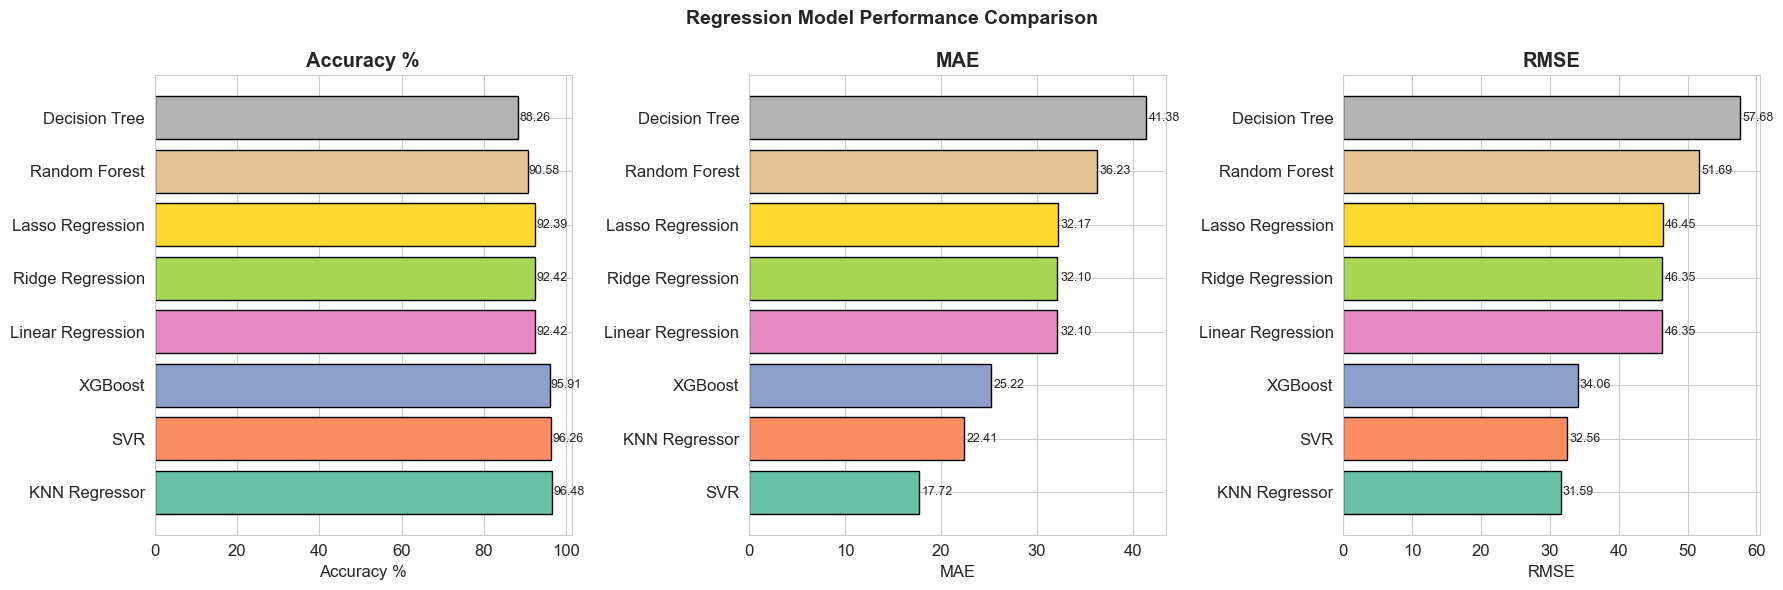

In [51]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette('Set2', len(results_df))

for ax, metric in zip(axes, ['Accuracy %', 'MAE', 'RMSE']):
    order = results_df.sort_values(metric, ascending=(metric != 'Accuracy %'))
    bars = ax.barh(order['Model'], order[metric], color=colors, edgecolor='black')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, order[metric]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Regression Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# Best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2 Score']
best_acc = results_df.iloc[0]['Accuracy %']
best_model_obj, best_preds = trained_models[best_model_name]

print(f'Best Model  : {best_model_name}')
print(f'Accuracy    : {best_acc}%')
print(f'R2 Score    : {best_r2}')
print(f'MAE         : {results_df.iloc[0]["MAE"]}')
print(f'RMSE        : {results_df.iloc[0]["RMSE"]}')

Best Model  : KNN Regressor
Accuracy    : 96.48%
R2 Score    : 0.9648
MAE         : 22.4083
RMSE        : 31.5894


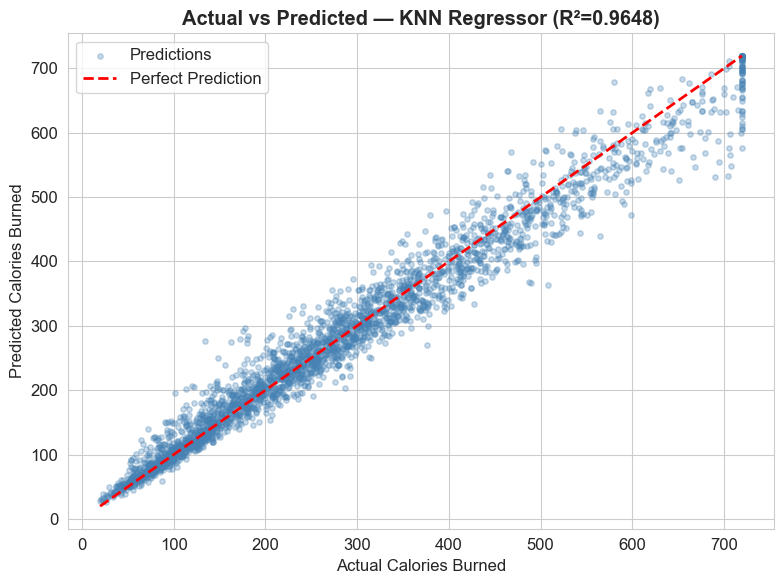

In [53]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.3, s=15, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title(f'Actual vs Predicted — {best_model_name} (R²={best_r2})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

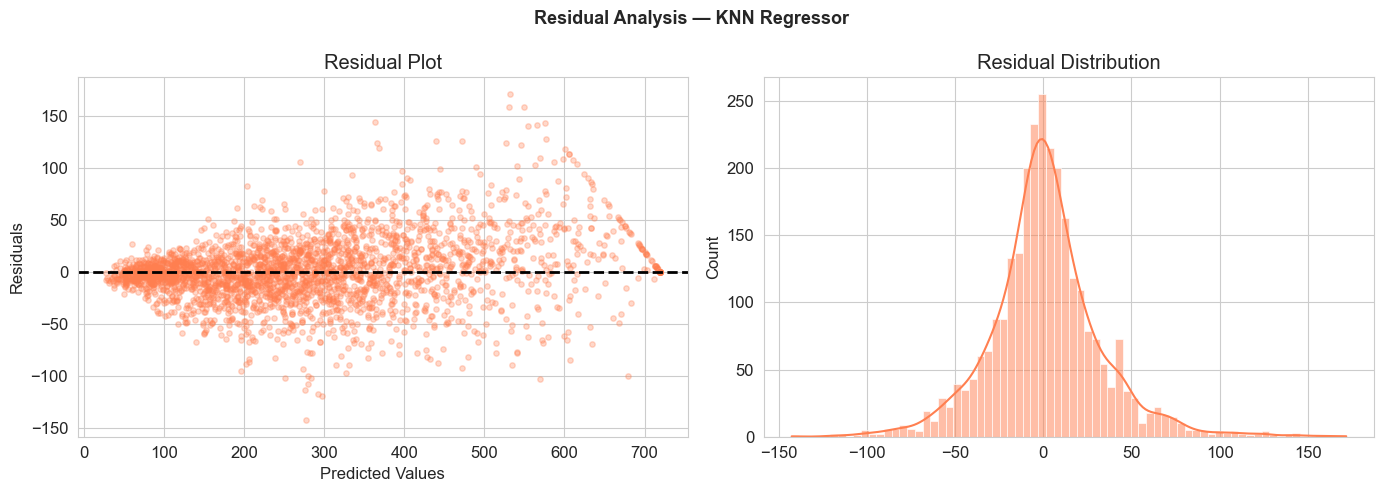

In [54]:
# Residual analysis
residuals = y_test.values - best_preds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(best_preds, residuals, alpha=0.3, s=15, color='coral')
axes[0].axhline(0, color='black', lw=2, linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')
sns.histplot(residuals, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Residual Distribution')
plt.suptitle(f'Residual Analysis — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

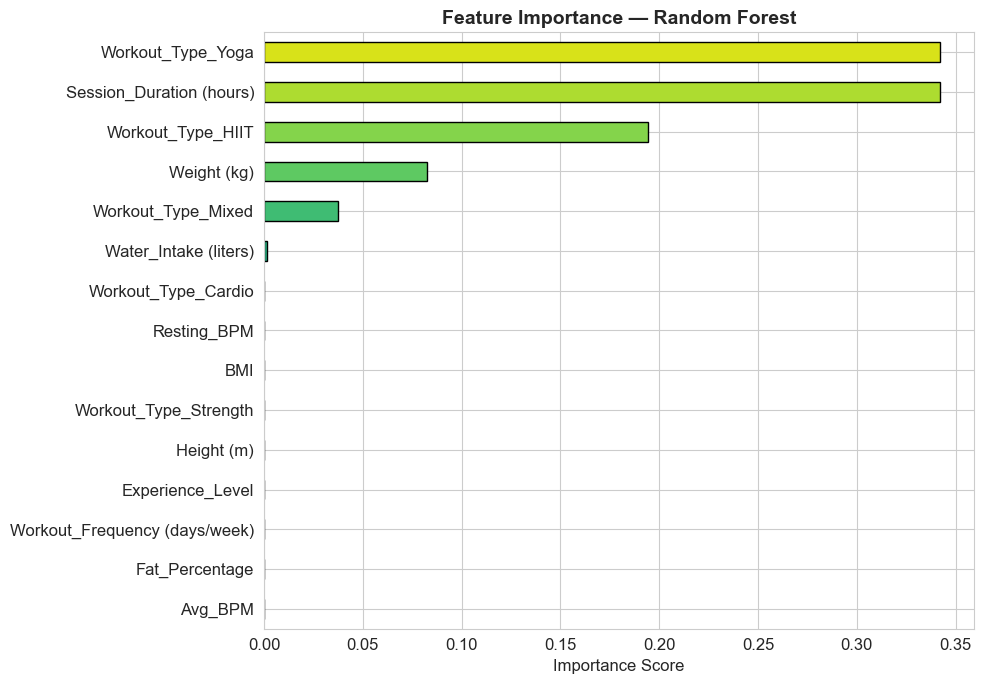

Top 5 Features:
Workout_Type_Yoga           0.342217
Session_Duration (hours)    0.342156
Workout_Type_HIIT           0.194574
Weight (kg)                 0.082487
Workout_Type_Mixed          0.037254
dtype: float64


In [55]:
# Feature Importance
tree_models_list = ['Random Forest', 'XGBoost', 'Decision Tree']
fi_model_name = next((m for m in tree_models_list if m in trained_models), None)

if fi_model_name:
    fi_model, _ = trained_models[fi_model_name]
    importances = pd.Series(fi_model.feature_importances_, index=selected_features)
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    importances.plot(kind='barh', color=sns.color_palette('viridis', len(importances)),
                     edgecolor='black')
    plt.title(f'Feature Importance — {fi_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Top 5 Features:')
    print(importances.sort_values(ascending=False).head())

In [56]:
# Cross-Validation
print(f'5-Fold Cross-Validation: {best_model_name}')
cv_scores = cross_val_score(best_model_obj, X_scaled, y, cv=5, scoring='r2', n_jobs=-1)
print(f'CV R2 Scores : {np.round(cv_scores, 4)}')
print(f'Mean CV R2   : {cv_scores.mean():.4f}')
print(f'Std Dev      : {cv_scores.std():.4f}')

5-Fold Cross-Validation: KNN Regressor
CV R2 Scores : [0.9672 0.9659 0.9637 0.9642 0.9649]
Mean CV R2   : 0.9652
Std Dev      : 0.0013


# Task 2: Workout Pattern Clustering (KMeans + PCA)

In [57]:
# Prepare clustering data
df_cluster = df_encoded.drop(columns=['Calories_Burned (kcal)'])
print(f'Clustering feature shape: {df_cluster.shape}')
print(f'Features: {df_cluster.columns.tolist()}')

Clustering feature shape: (14102, 19)
Features: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Gender_Female', 'Gender_Male', 'Workout_Type_Cardio', 'Workout_Type_HIIT', 'Workout_Type_Mixed', 'Workout_Type_Strength', 'Workout_Type_Yoga']


In [58]:
# Scale clustering features
scaler_cl = StandardScaler()
X_cluster = scaler_cl.fit_transform(df_cluster)
print('Clustering features scaled.')

Clustering features scaled.


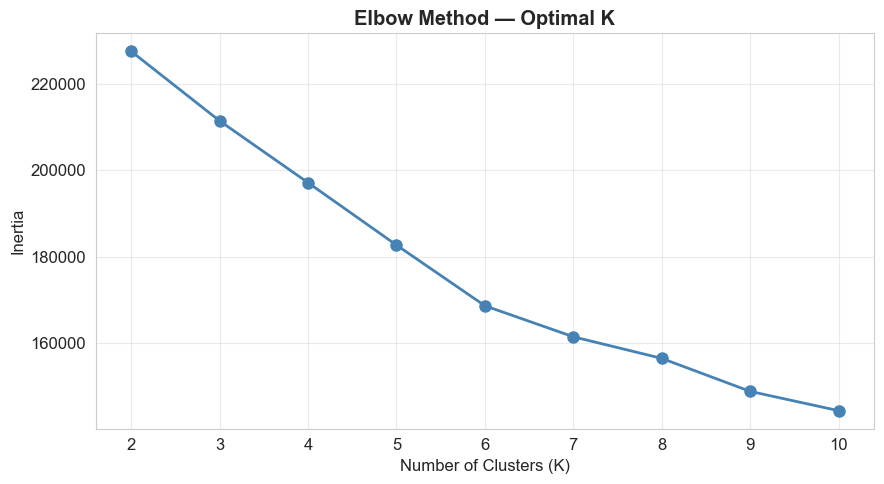

In [59]:
# Elbow Method
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K', fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# PCA 2D reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
print(f'PCA Variance Explained: {pca.explained_variance_ratio_}')
print(f'Total Variance        : {pca.explained_variance_ratio_.sum():.2%}')

PCA Variance Explained: [0.20624887 0.13565963]
Total Variance        : 34.19%


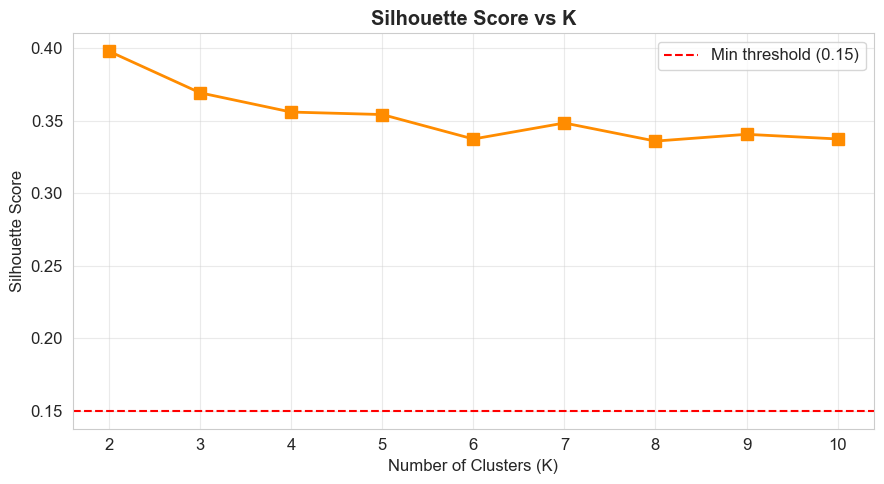

Selected K = 4
Silhouette Score at K=4: 0.3559


In [61]:
# Silhouette score for different K
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(9, 5))
plt.plot(K_range, sil_scores, marker="s", color="darkorange", linewidth=2, markersize=8)
plt.axhline(0.15, color="red", linestyle="--", label="Min threshold (0.15)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K", fontweight="bold")
plt.xticks(K_range)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()

# K=4 chosen: best balance of cluster quality and interpretability
best_k = 4
print(f"Selected K = {best_k}")
print(f"Silhouette Score at K=4: {sil_scores[K_range.index(4) if hasattr(K_range, "index") else list(K_range).index(4)]:.4f}")


In [62]:
# KMeans on PCA data
OPTIMAL_K = best_k
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

final_sil = silhouette_score(X_pca, cluster_labels)
print(f'KMeans Applied | K={OPTIMAL_K} | Silhouette Score={final_sil:.4f}')
print('\nCluster Distribution:')
print(pd.Series(cluster_labels).value_counts().sort_index())

KMeans Applied | K=4 | Silhouette Score=0.3559

Cluster Distribution:
0    4406
1    3022
2    3858
3    2816
Name: count, dtype: int64


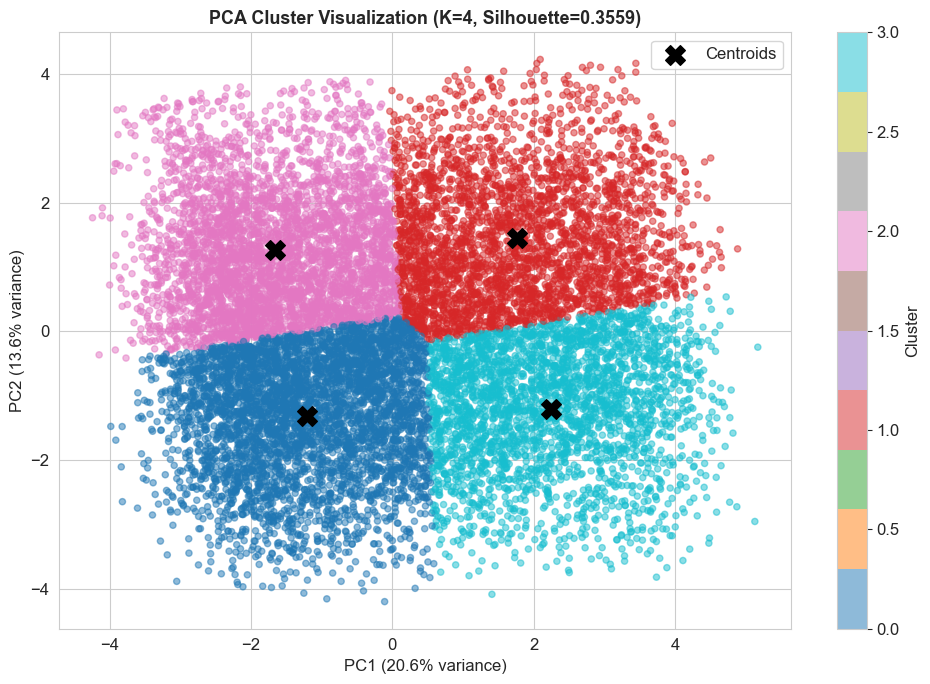

In [63]:
# PCA Cluster Visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.5, s=20)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200,
            marker='X', label='Centroids', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'PCA Cluster Visualization (K={OPTIMAL_K}, Silhouette={final_sil:.4f})',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# Cluster profile analysis
df_cluster_analysis = df_cluster.copy()
df_cluster_analysis['Cluster'] = cluster_labels
df_cluster_analysis['Calories_Burned (kcal)'] = df_encoded['Calories_Burned (kcal)'].values
profile = df_cluster_analysis.groupby('Cluster').mean(numeric_only=True).round(2)
print('=== Cluster Feature Means ===')
profile

=== Cluster Feature Means ===


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Mixed,Workout_Type_Strength,Workout_Type_Yoga,Calories_Burned (kcal)
Cluster,,,,,,,,,,,,,,,,,,,,
0,46.59,68.23,1.68,172.72,139.11,72.95,0.67,25.13,3.40,3.14,0.45,24.07,0.54,0.46,0.25,0.11,0.15,0.20,0.29,194.82
1,30.02,68.04,1.68,190.61,157.31,64.05,1.06,17.45,3.93,5.59,2.14,24.06,0.46,0.54,0.14,0.29,0.30,0.20,0.08,403.61
2,29.59,68.62,1.68,191.13,160.41,73.66,0.65,25.10,3.29,3.03,0.39,24.22,0.50,0.50,0.19,0.35,0.18,0.21,0.07,258.90
3,47.29,67.85,1.68,171.77,134.69,63.42,1.08,16.95,3.98,5.72,2.23,23.98,0.45,0.55,0.20,0.08,0.19,0.19,0.34,295.52


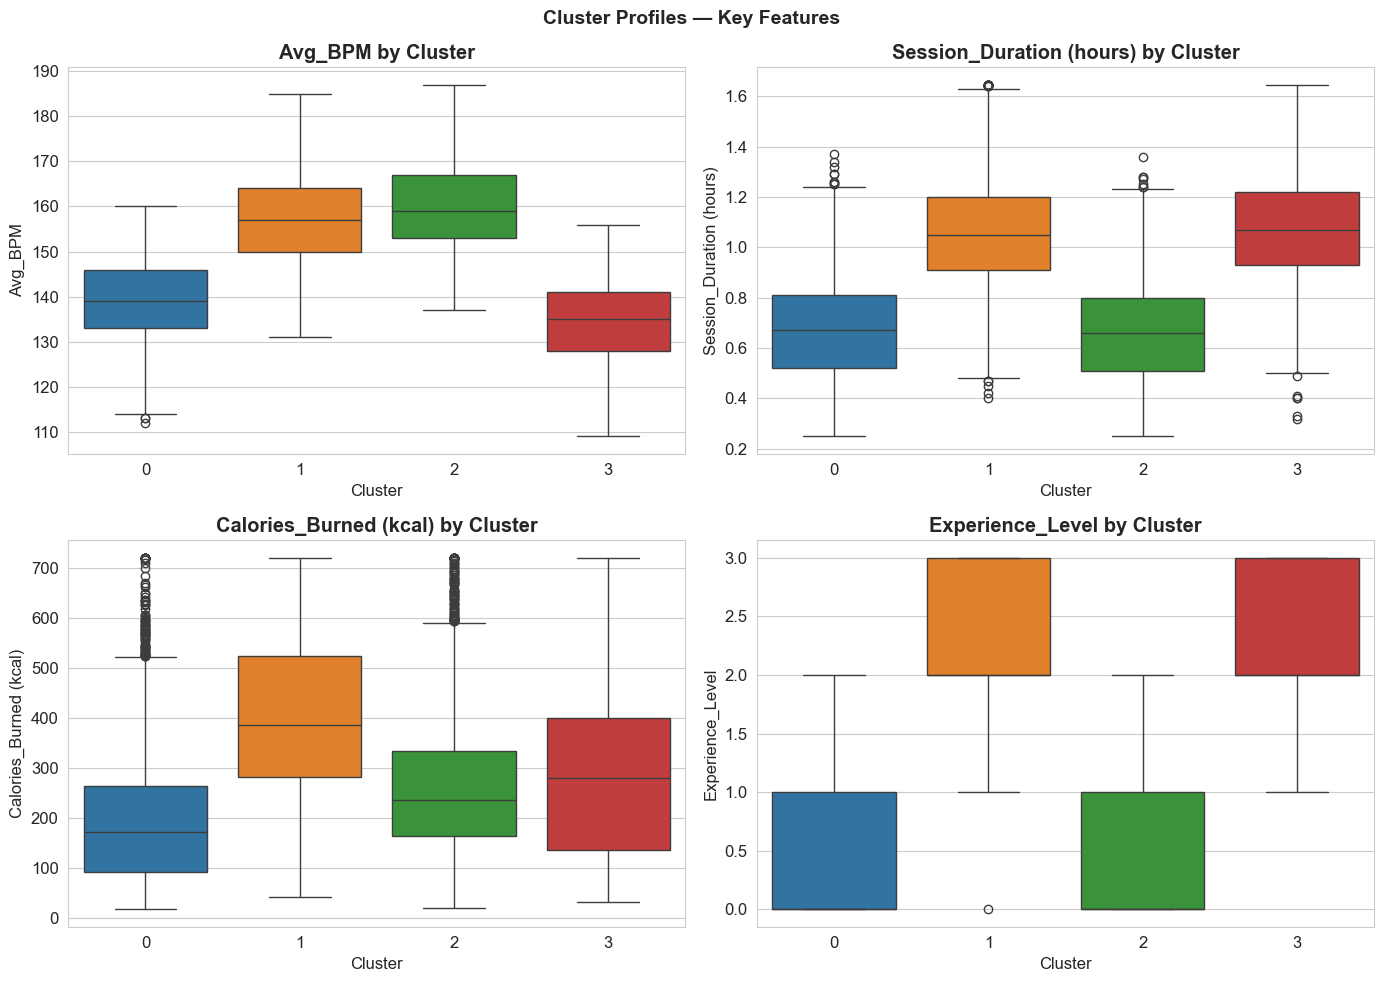

In [65]:
# Cluster boxplots
key_feats = ['Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned (kcal)', 'Experience_Level']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(key_feats):
    sns.boxplot(data=df_cluster_analysis, x='Cluster', y=col, ax=axes[i], palette='tab10')
    axes[i].set_title(f'{col} by Cluster', fontweight='bold')
plt.suptitle('Cluster Profiles — Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 Final Summary

In [66]:
print('=' * 60)
print('     FITBIT PROJECT — FINAL RESULTS SUMMARY')
print('=' * 60)

print('\nPIPELINE STEPS:')
print('  1. Data Loading')
print('  2. Basic Cleaning (nulls, duplicates, outliers, leaky cols)')
print('  3. One-Hot Encoding (Gender, Workout_Type)')
print('  4. Correlation-based Feature Selection (threshold=0.05)')
print('  5. Standard Scaling (StandardScaler)')
print('  6. Train-Test Split (80% train / 20% test)')

print('\nTASK 1 — REGRESSION RESULTS:')
print(results_df[['Model','MAE','RMSE','R2 Score','Accuracy %']].to_string(index=False))
print(f'\nBest Model  : {best_model_name}')
print(f'Accuracy    : {best_acc}%')
print(f'R2 Score    : {best_r2}')

print('\nTASK 2 — CLUSTERING RESULTS:')
print(f'  Algorithm        : KMeans + PCA')
print(f'  Optimal K        : {OPTIMAL_K}')
print(f'  Silhouette Score : {final_sil:.4f}')
print(f'  PCA Variance     : {pca.explained_variance_ratio_.sum():.2%}')

print('\nAll charts saved as PNG files in project folder!')
print('=' * 60)

     FITBIT PROJECT — FINAL RESULTS SUMMARY

PIPELINE STEPS:
  1. Data Loading
  2. Basic Cleaning (nulls, duplicates, outliers, leaky cols)
  3. One-Hot Encoding (Gender, Workout_Type)
  4. Correlation-based Feature Selection (threshold=0.05)
  5. Standard Scaling (StandardScaler)
  6. Train-Test Split (80% train / 20% test)

TASK 1 — REGRESSION RESULTS:
            Model     MAE    RMSE  R2 Score  Accuracy %
    KNN Regressor 22.4083 31.5894    0.9648       96.48
              SVR 17.7159 32.5616    0.9626       96.26
          XGBoost 25.2227 34.0643    0.9591       95.91
Linear Regression 32.1020 46.3522    0.9242       92.42
 Ridge Regression 32.1032 46.3533    0.9242       92.42
 Lasso Regression 32.1654 46.4523    0.9239       92.39
    Random Forest 36.2280 51.6864    0.9058       90.58
    Decision Tree 41.3753 57.6779    0.8826       88.26

Best Model  : KNN Regressor
Accuracy    : 96.48%
R2 Score    : 0.9648

TASK 2 — CLUSTERING RESULTS:
  Algorithm        : KMeans + PCA
  O